# CMSC320 Programming Assignment 5
Please go through the file following the instructions as you go.

Rename this notebook to `CMSC320_PA5_YourName.ipynb`

Note that there may be quite a few functions for you to look up in this one. Welcome to the life of a Data Scientist!

#  Data Science Consultancy for Mr. Grapeglamour's Winery Revamp🍷✨

## Background:
Mr. Gaurav Grapeglamour, a prominent wine baron, seeks consultancy services from your company to modernize his traditional wine breweries and distribution systems.

As part of the consultancy, we will utilize **"the Red Wine Quality dataset"** (on Canvas) to analyze and classify the quality of Grapeglamour's red wines. By leveraging data science techniques, we aim to optimize processes, minimize losses, and enhance overall wine quality.

*The Red Wine Quality dataset contains various physicochemical properties of red wines along with their quality ratings on a scale from 0 to 10.*

Feel free to create new cells/comments.

### Part 1 (6 points total)
#### To start, you have been asked to produce a summary of data received from the client.

##### **1.1 (1 point)** Import libraries
Import the following libraries (the rest of the library declarations are done for you below):
- **numpy** as *np*
- **pandas** as *pd*

In [1]:
# Write your code here

import numpy as np
import pandas as pd 

In [2]:
#Run this cell
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

##### **1.2 (1 point)** Load the dataset
Load the Red Wine Quality dataset into a dataframe named **wine_data**.

In [3]:
# Write your code here

wine_data = pd.read_csv('winequality-red.csv')

##### Explore the Data
Let's see what's inside the dataset first to get a feel for it. Write only a **single line** of code for each task.

**1.3 (1 point)** Print the number of **Samples** (rows) in the dataset.

In [10]:
# Write your code here 

print(wine_data.shape)
wine_data.shape[0]

(1599, 12)


1599

**1.4 (1 point)** Print the number of **Features** in the dataset, excluding Quality which is a label.

In [ ]:
# Write your code here

wine_data.shape[1] - 1 # deducting the last column which is quality

11

**1.5 (1 point)** Print the **unique** values in the *Quality* column.

In [11]:
# Write your code here

wine_data['quality'].unique()

array([5, 6, 7, 4, 8, 3])

##### **1.6 (1 points)** Preprocessing of the Data
Before we dive deep, we need to prep the data to make it usable.

Handle the **missing values** in the data by **discarding them.** Meaning, drop the rows which have any missing values.

In [12]:
# Write your code here

wine_data = wine_data.dropna()

### Part 2: Data Visualization (8 points total)
The matplotlib and seaborn libraries are great tools for visualizing data.

They are used to create very legible and complex graphs that are essential in data interpretation and analysis.

In [13]:
#run this cell
import matplotlib.pyplot as plt
import seaborn as sns

##### **2.1 (6 points)** Visualize the distribution of each feature in the original dataset for different quality values.
- **Plot** out a histogram for each feature (Useful to use a for loop)
- Note: each histogram is actually *n* histograms next to each other, one for each unique value of *Quality*.
- Label the **title** of each histogram "Distribution of [Feature Name] by Quality"
- Label the **axes** appropriately and display each histogram.

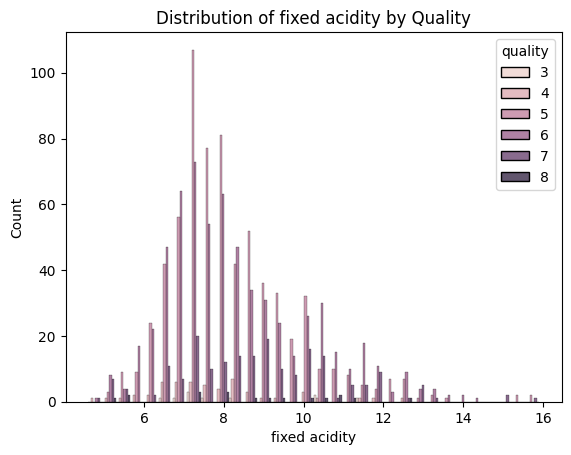

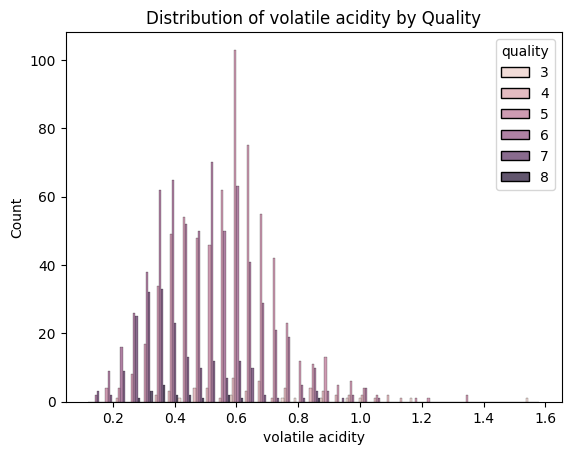

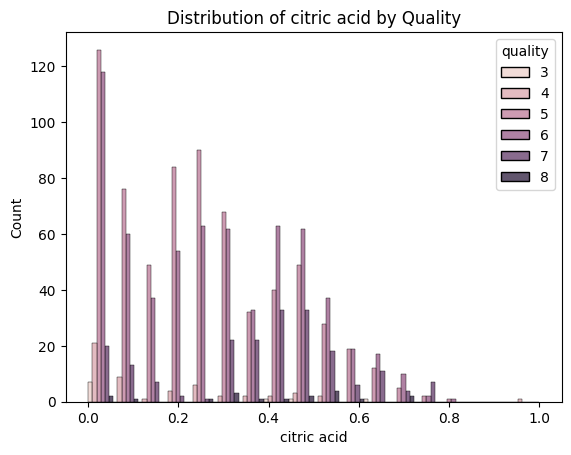

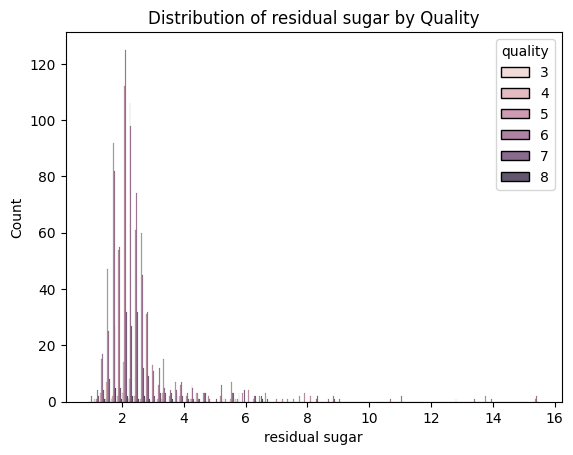

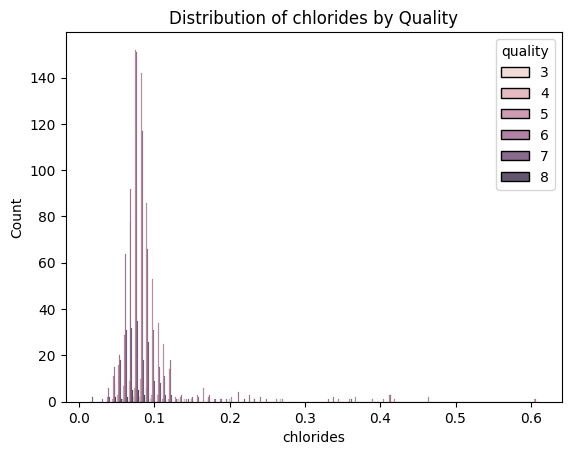

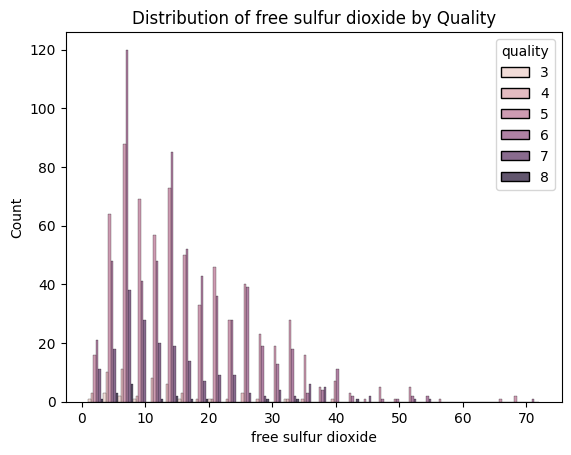

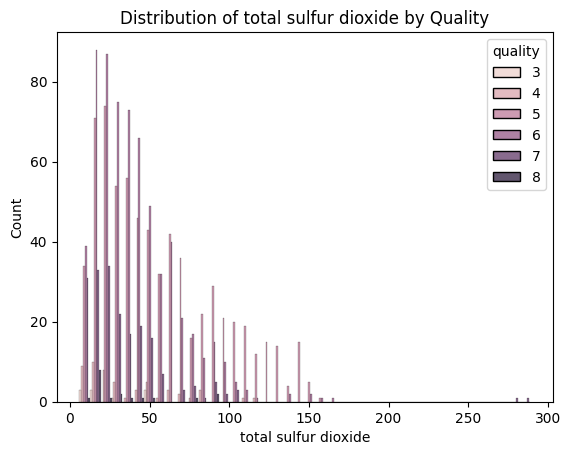

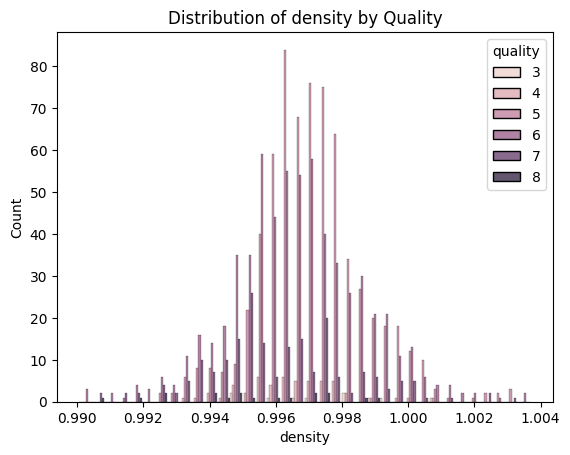

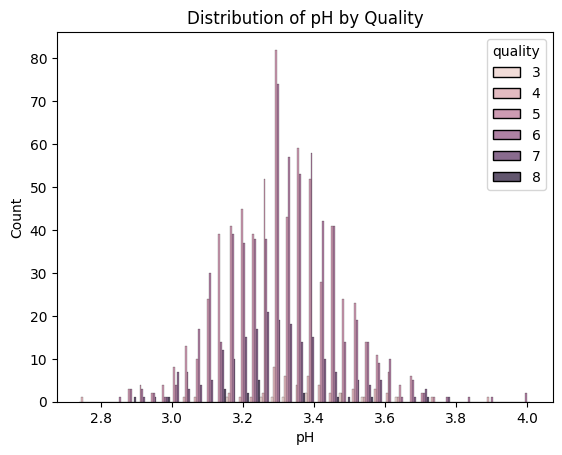

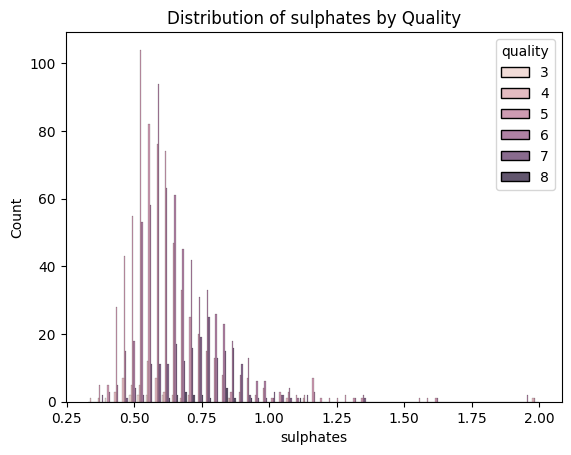

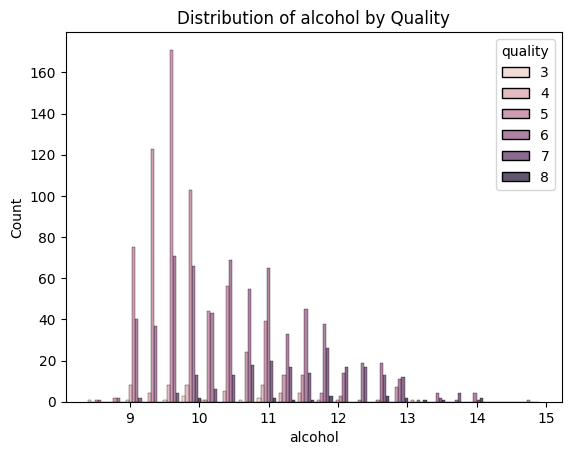

In [ ]:
for feature in wine_data.columns[:-1]:  # Exclude the 'quality' column
  # Write your code here
    plt.figure()
    sns.histplot(data=wine_data, x=feature, hue='quality', multiple='dodge') # plotting with separation (dodge) and gradual quality representations by color hue changes
    plt.title(f'Distribution of {feature} by Quality')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

##### **2.2 (2 points)** Explore correlations between features and quality ratings.
- Create a **correlation matrix** based on the correlations between features and quality
- **Display** the matrix

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.256131     0.671703   
volatile acidity          -0.256131          1.000000    -0.552496   
citric acid                0.671703         -0.552496     1.000000   
residual sugar             0.114777          0.001918     0.143577   
chlorides                  0.093705          0.061298     0.203823   
free sulfur dioxide       -0.153794         -0.010504    -0.060978   
total sulfur dioxide      -0.113181          0.076470     0.035533   
density                    0.668047          0.022026     0.364947   
pH                        -0.682978          0.234937    -0.541904   
sulphates                  0.183006         -0.260987     0.312770   
alcohol                   -0.061668         -0.202288     0.109903   
quality                    0.124052         -0.390558     0.226373   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

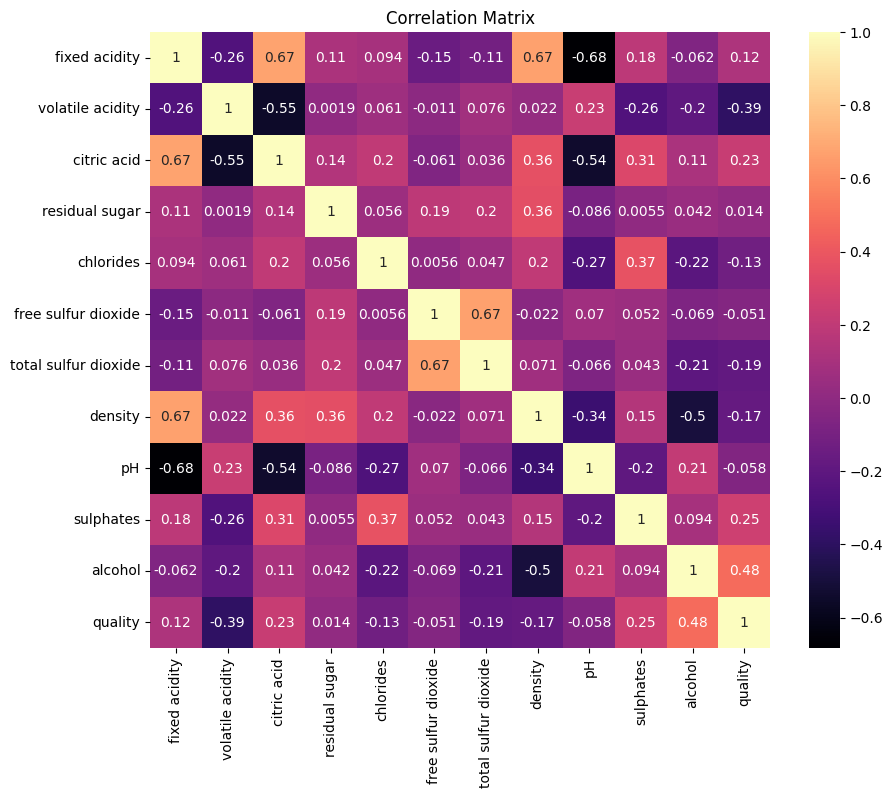

In [ ]:
# Write your code here

corr_matrix = wine_data.corr()
print(corr_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='magma')
plt.title('Correlation Matrix')
plt.show()

### Part 3 (8 points total)
#### Your manager, Aishani Applecider, has asked you to utilize the data provided by Mr. Grapeglamour's wine brewery and come up with a model to predict whether to place each wine in the expensive wine aisle or not.

#### Let's prepare the data first!

***(Expensive wine = the quality of wine is strictly > 6)***

##### Feature Engineering

**3.1 (2 points)** *Quality* is a label and won't be used in our analysis. But perhaps we want to use another, binary label called *Expensive*. Create a new column called *Expensive* and make it 1 or 0 depending on the Quality value for each observation.

In [17]:
# Write your code here

wine_data['Expensive'] = (wine_data['quality'] > 6).astype(int)

**3.2 (2 points)** Standardize the **feature** set in order to make sure that the machine learning model is not biased by differences in scales/units within the data. Standardizations aids with consistency in the data.

*Hints: Look into these functions and classes* [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [19]:
# Write your code here

X = wine_data.drop(['quality', 'Expensive'], axis = 1)
y = wine_data['Expensive']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


##### Splitting, Training, and Testing
Typically in Machine learning, we wish to split the data into various portions in order to test a machine learning model on one part of the data and test it on another part of the data. This is to evaluate the model's performance on the dataset.

Training data is used to teach the model, while testing data assesses its generalization to unseen examples.

Splitting helps prevent overfitting, ensuring the model can make accurate predictions on new, unseen data.

**3.3 (2 points)** First, create a **features** object (**X**) and **the target label** object (**y**). X is a dataframe (a collection of columns) while y is just one column/vector.

In [ ]:
# Write your code here
X = X.values # defined feature set in previous cell to scale
y = y.values # defined vector in previous cell so calling values


**3.4 (2 points)** Split the features and target labels into **training and testing sets**. This is approximately 1 line of code. Test size should be **0.3**.

*Hint: Look into this function* [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [21]:
# pass this seed value to your argument: seed = 42

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42) # Write your code here

# 70/30

### Part 4 (10 points total)

#### Your promotion is dependent on this project. Hence, Ms. Applecider asks you to be thorough with your model search. You are asked to train 4 different classifiers, namely **KNN**, **DecisionTree**, **Logistic Regression**, and **Random Forest**.

In [22]:
#run this cell to put your models in a dictionary and be able to iterate over them

models = {
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(),
    'LogisticRegression': LogisticRegression(),
    'RandomForest': RandomForestClassifier()
}

##### **4.1 (3 points)** Train each of the models.

**Note:** We are not using validation or hyperparameter tuning right now. You can run each model with default parameters (i.e. no arguments provided to the function). And we will try each model on our test set.

In [23]:
# Train each model using the training data
for model_name, model in models.items():
  # Write your code here
  model.fit(X_train,y_train)
  print(f"{model_name} trained")
  
  

KNN trained
DecisionTree trained
LogisticRegression trained
RandomForest trained


##### **4.2 (4 points)** Test each model

- Print the **accuracy** of each model in this **format**: Accuracy of [model name]: [accuracy of the model].
- Print a **classification report** for each model that lists its accuracy, precision, recall and f1-score.

*Hint: Look into this function!* [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

In [24]:
# Evaluate the performance of each model
for model_name, model in models.items():
  # Write your code here
  y_prediction = model.predict(X_test)
  print(f"Accuracy of {model_name}: {accuracy_score(y_test, y_prediction)}")
  print(f"Classification Report for {model_name}:\n{classification_report(y_test, y_prediction)}")

Accuracy of KNN: 0.8708333333333333
Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       413
           1       0.55      0.45      0.49        67

    accuracy                           0.87       480
   macro avg       0.73      0.69      0.71       480
weighted avg       0.86      0.87      0.87       480

Accuracy of DecisionTree: 0.85625
Classification Report for DecisionTree:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       413
           1       0.49      0.61      0.54        67

    accuracy                           0.86       480
   macro avg       0.71      0.75      0.73       480
weighted avg       0.87      0.86      0.86       480

Accuracy of LogisticRegression: 0.8645833333333334
Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       413

##### **4.3 (3 points)** Model Interpretation
- **Interpret** the results of the classification models (list the models which got the best scores for Accuracy, Precision, Recall and F1 score).
- Recommend the best model according to your analysis.

**Answer here**

The performance of across all four models varied about accuracy and metrics concerning precision, recall, F1-score, and support. For expensive classified wine (=1), a;; the models were quite accurate, but random forrest performed the best with the most overall balance between its outputs and overall accuracy of answers. The differences between predicted and actual values were not as high and it showcased how different models applied better in accordance with certain situations. With high precision and F1-score as well for expensive wine, the strength of the model stood out amongst competitors like decision tree and logistic regression. KNN performed the second best out of them all. Other models sacrificed things like precision for recall and vice-versa (not as easy).

### Part 5. Feedback (1 point total)

#### Please share what you enjoyed and didn't enjoy about this assignment and how long it took for you to do it.

*Share your thoughts here:*

THis assignment was well put together and quite enjoyable for learning and applying multiple machine learning models. The comparison of their unique performances on an interesting dataset was helpful for my general understanding of the intersection of feature engineering and data preprocessing. By standardizing our data before working with our model and looking at documentation for our specific situation, things came together quite easily in a reasonable amount of time (1 hour). 

### Part 6. Submitting your work

### Congrats on finishing PA5!

1. Save this notebook (`File > Save`).
2. Download it to your computer as `.ipynb` (`File > Download > Download .ipynb`).
3. Submit the .ipynb file on Canvas.

Tips:
1. After finishing the work, click on the arrow to the right of "Run all" and then click on "Clear all outputs" and "Restart session." Then run each cell in order to make sure everything compiles.
2. Remember to delete the cells you created for testing and any Gemini-affected cells if you used help from Gemini.